In [ ]:
# Import STIR
import sirf.STIR as PET
import numpy as np
import matplotlib.pyplot as plt
from sirf.Utilities import show_2D_array
import math

In [10]:
# Create an acquisition template
acq_template_filename = "scanner.hs"

In [11]:
# Suppress unnecessary error messages
msg_red = PET.MessageRedirector()

In [14]:
# The geometry in the acquisition template is read
acq_template = PET.AcquisitionData(acq_template_filename)

You may need to close Figure 1 window to continue...


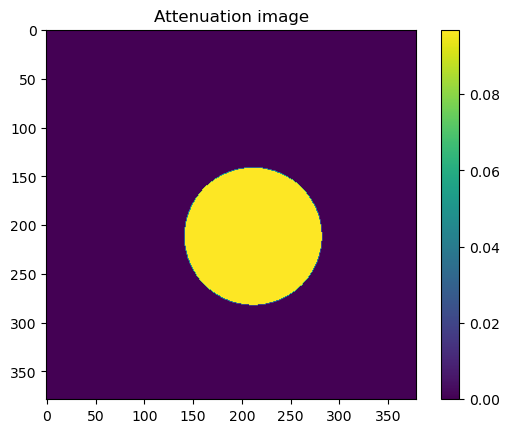

You may need to close Figure 1 window to continue...


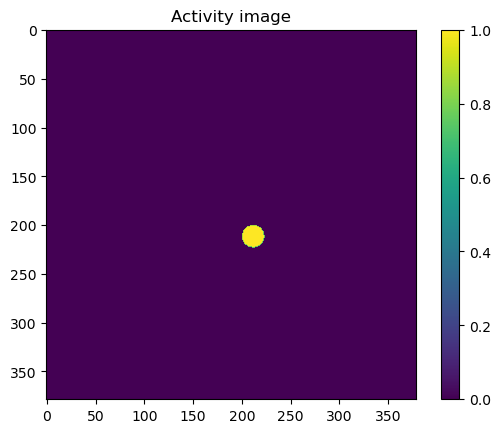

In [204]:
# create the attenuation image
atten_image = PET.ImageData(acq_template)
image_size = atten_image.dimensions()
voxel_size = atten_image.voxel_sizes()

# create a cylindrical water phantom
water_cyl = PET.EllipticCylinder()
water_cyl.set_length(image_size[0]*voxel_size[0])
water_cyl.set_radii((image_size[1]*voxel_size[1] * 0.18576, \
                    image_size[2]*voxel_size[2] * 0.18576)) ##STIR takes mm
water_cyl.set_origin((0, image_size[1]*voxel_size[1]*0.06, \
                      image_size[2] * voxel_size[2] * 0.06))

# add the shape to the image
atten_image.add_shape(water_cyl, scale = 9.687E-02)

# z-pixel coordinate of the xy-crossection to show
z = int(image_size[0]*0.5)

# show the phantom image
atten_image_array = atten_image.as_array()
show_2D_array('Attenuation image', atten_image_array[z,:,:])

# Create the activity image
act_image = atten_image.clone()
act_image.fill(0.0)

# create the activity cylinder
act_cyl = PET.EllipticCylinder()
act_cyl.set_length(image_size[0] * voxel_size[0])
act_cyl.set_radii((image_size[1] * voxel_size[1] * 0.03, \
                        image_size[2] * voxel_size[2] * 0.03))
act_cyl.set_origin((0, image_size[1] * voxel_size[1] * 0.06, \
                        image_size[2] * voxel_size[2] * 0.06))

# add the shape to the image
act_image.add_shape(act_cyl, scale=1)

# z-pixel coordinate of the xy-crossection to show
z = int(image_size[0] * 0.5)

# show the phantom image
act_image_array = act_image.as_array()
show_2D_array('Activity image', act_image_array[0,:,:])

In [ ]:
# Export attenuation and activity images
atten_image.write('2.9.2/atten_image')
act_image.write('2.9.2/act_image')

In [ ]:
# Create the Single Scatter Simulation model
sss = PET.SingleScatterSimulator()

# Set the attenuation image
sss.set_attenuation_image(atten_image)

# set-up the scatter simulator
sss.set_up(acq_template, act_image)
# simulate
sss_data = sss.forward(act_image)

In [ ]:
# SSS visualisation 
stir_scatter = sss_data.as_array()
show_2D_array('Simulated SSS', stir_scatter[0,5,:,:])
sss_data.write("Single_Scatter")

# Move on to SimSET

Help on ImageData in module sirf.STIR object:

class ImageData(sirf.SIRF.ImageData)
 |  ImageData(arg=None)
 |  
 |  Class for PET image data objects.
 |  
 |  ImageData objects contain both geometric data and the actual voxel
 |  values. You have to use the `as_array` method to get an array with
 |  the voxel values, and use the `fill` function to change the voxel values.
 |  
 |  Method resolution order:
 |      ImageData
 |      sirf.SIRF.ImageData
 |      sirf.SIRF.DataContainer
 |      abc.ABC
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __del__(self)
 |      Deallocates this ImageData object.
 |  
 |  __init__(self, arg=None)
 |      Creates an ImageData object.
 |      
 |      Arguments:
 |          arg : Python str or AcquisitionData or None, interpreted as follows:
 |      str            : read the object from a file specified by <arg>
 |                       (the file format has to be support by STIR).
 |      PET.AcquisitionData: create an object compati

In [254]:
# Read the SimSET output into matrices
# blue0_pink0 is the nonscatter histogram
blue0_pink0 = np.zeros((10,10))
for w1 in range(10):
   for w2 in range(10):
      blue0_pink0[w1, w2] = PET.AcquisitionData(f"8.10/scatter_param=3/blue0_en{w1}_pink0_en{w2}.hs").sum()
nonscatter_histogram = blue0_pink0

# all other three comprise the scatter histogram
blue0_pink1 = np.zeros((10,10))
for w1 in range(10):
   for w2 in range(10):
      blue0_pink1[w1, w2] = PET.AcquisitionData(f"8.10/scatter_param=3/blue0_en{w1}_pink1_en{w2}.hs").sum()

blue1_pink0 = np.zeros((10,10))
for w1 in range(10):
   for w2 in range(10):
      blue1_pink0[w1, w2] = PET.AcquisitionData(f"8.10/scatter_param=3/blue1_en{w1}_pink0_en{w2}.hs").sum()

blue1_pink1 = np.zeros((10,10))
for w1 in range(10):
   for w2 in range(10):
      blue1_pink1[w1, w2] = PET.AcquisitionData(f"8.10/scatter_param=3/blue1_en{w1}_pink1_en{w2}.hs").sum()
scatter_histogram = blue0_pink1 + blue1_pink0 + blue1_pink1
# Non-scatter + scatter generates the total histogram
total_histogram = nonscatter_histogram + scatter_histogram

the Interfile header, and remaining fields set from the
	ECAT 962 model.



Value in header is 1.27273 while the default for the scanner is 0.225
Using value from header.








	from the Interfile header, and remaining fields set from the
	ECAT 962 model.



Value in header is 1.27273 while the default for the scanner is 0.225
Using value from header.








	from the Interfile header, and remaining fields set from the
	ECAT 962 model.



Value in header is 1.27273 while the default for the scanner is 0.225
Using value from header.








	from the Interfile header, and remaining fields set from the
	ECAT 962 model.



Value in header is 1.27273 while the default for the scanner is 0.225
Using value from header.








	from the Interfile header, and remaining fields set from the
	ECAT 962 model.



Value in header is 1.27273 while the default for the scanner is 0.225
Using value from header.








	from the Interfile header, and remaining fields set from the
	ECAT 962 model.




([<matplotlib.axis.YTick at 0x7fffdacc25c0>,
 [Text(0, 0, '0'),
  Text(0, 1, '1'),
  Text(0, 2, '2'),
  Text(0, 3, '3'),
  Text(0, 4, '4'),
  Text(0, 5, '5'),
  Text(0, 6, '6'),
  Text(0, 7, '7'),
  Text(0, 8, '8'),
  Text(0, 9, '9')])

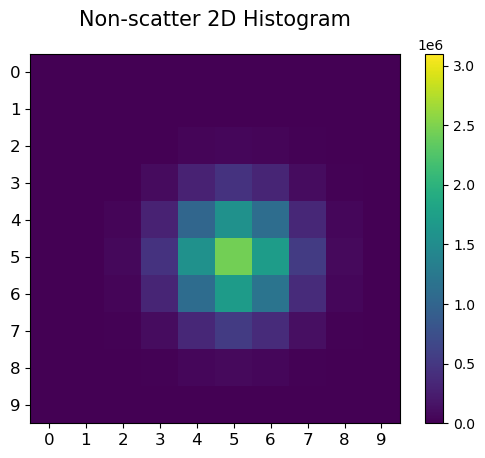

In [255]:
# Visualise these histograms individually under the same scale
# Non-scatter histogram
plt.imshow(nonscatter_histogram, vmin=0, vmax=3100000)
plt.colorbar()
plt.title("Non-scatter 2D Histogram", fontsize = 15, pad = 20)
plt.xticks(np.arange(0, 10, 1), fontsize = 12)
plt.yticks(np.arange(0, 10, 1), fontsize = 12)

([<matplotlib.axis.YTick at 0x7fffdaaa14e0>,
 [Text(0, 0, '0'),
  Text(0, 1, '1'),
  Text(0, 2, '2'),
  Text(0, 3, '3'),
  Text(0, 4, '4'),
  Text(0, 5, '5'),
  Text(0, 6, '6'),
  Text(0, 7, '7'),
  Text(0, 8, '8'),
  Text(0, 9, '9')])

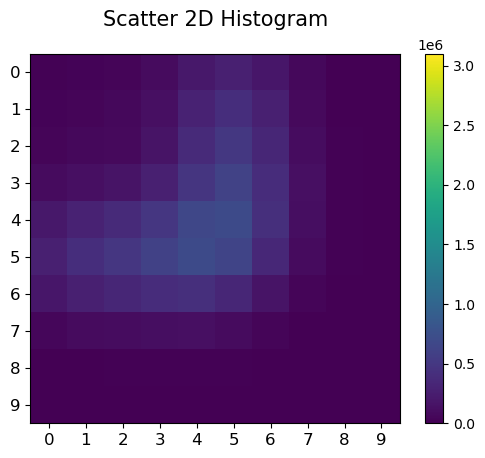

In [226]:
# Scatter histograms
plt.imshow(scatter_histogram, vmin=0, vmax=3100000)
plt.colorbar()
plt.title("Scatter 2D Histogram", fontsize = 15, pad = 20)
plt.xticks(np.arange(0, 10, 1), fontsize = 12)
plt.yticks(np.arange(0, 10, 1), fontsize = 12)

In [ ]:
# Total histogram
plt.imshow(total_histogram, vmin=0, vmax=3100000)
plt.colorbar()
plt.title("Total 2D Histogram", fontsize = 15, pad = 20)
plt.xticks(np.arange(0, 10, 1), fontsize = 12)
plt.yticks(np.arange(0, 10, 1), fontsize = 12)

In [98]:
#Convert into 1D arrays
blue0_pink0_1D = np.sum(blue0_pink0, axis = 1)
blue0_pink1_1D = np.sum(blue0_pink1, axis = 1)
blue1_pink0_1D = np.sum(blue1_pink0, axis = 1)
blue1_pink1_1D = np.sum(blue1_pink1, axis = 1)

nonscatter_1D_histogram = blue0_pink0_1D
scatter_1D_histogram = blue0_pink1_1D + blue1_pink0_1D + blue1_pink1_1D
total_1D_histogram = nonscatter_1D_histogram + scatter_1D_histogram
total_1D_histogram

array([  900055.93902308,  1348738.29541779,  1847768.19459152,
        3561634.95651054,  7692876.67576408, 10410257.57969892,
        6947495.18518829,  2163727.11552191,   305213.68234253,
          19489.16187334])

Text(0.5, 1.0, 'Energy Spectra')

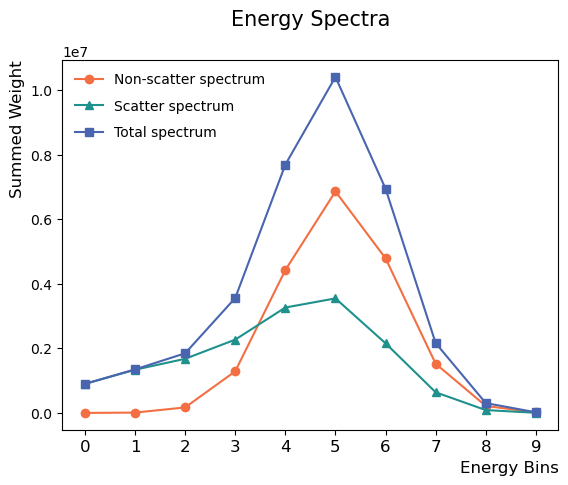

In [251]:
plt.plot(blue0_pink0_1D, color = "#f36f43", label = "Non-scatter spectrum", marker = "o", ms = 6)
plt.plot(blue0_pink1_1D+blue1_pink0_1D+blue1_pink1_1D, color = "#1F918D", label = "Scatter spectrum", marker = "^", ms = 6)
plt.plot(blue0_pink0_1D+blue0_pink1_1D+blue1_pink0_1D+blue1_pink1_1D, color = "#4965B0", label = "Total spectrum", marker = "s", ms = 6)
plt.xticks(np.arange(0, 10, 1), fontsize = 12)
plt.xlabel("Energy Bins", loc = "right", fontsize = 12)
plt.ylabel("Summed Weight", loc = "top", fontsize = 12)
plt.legend(loc = "upper left", frameon = False, fontsize = 10, labelspacing = 0.9)
plt.title("Energy Spectra", pad = 25, fontsize = 15)

In [236]:
# Estimate non-scatter PDF
FWHM = 511 * 0.1 #det.rec
sigma_511 = FWHM / math.sqrt(8 * math.log(2))
4*sigma_511

PDF_nonscatter = []
energies = list(range(410, 591, 20))
for i in (energies):
    PDF_nonscatter.append((1 / (math.sqrt(2 * math.pi) * sigma_511)) * math.exp((- ((i - 511) ** 2) / (2 * sigma_511 ** 2)))) #i: E
#U(E) every 20keV at the midpoint
np.trapz(PDF_nonscatter, energies)

0.9997415740749879

In [237]:
PDF_nonscatter

[3.63421055731582e-07,
 1.7335685149897804e-05,
 0.0003536421646233147,
 0.0030851705283309713,
 0.011510293882561608,
 0.018364781045856794,
 0.012530753932949638,
 0.0036564593799340048,
 0.0004562852279413215,
 2.4350291747952076e-05]

Text(0.5, 1.0, 'Non-scatter PDF &\nNormalised Non-scatter Component')

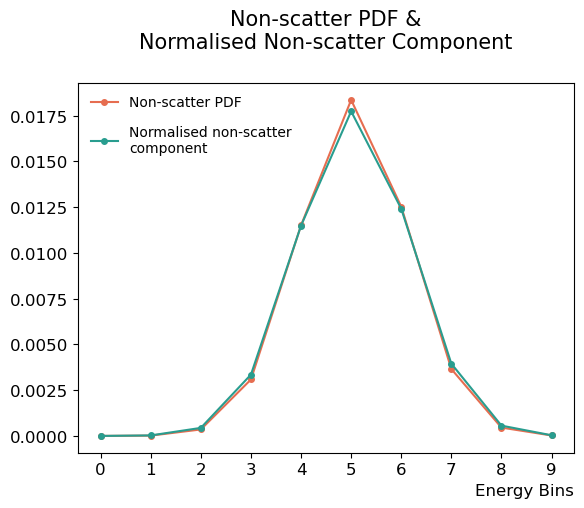

In [194]:
# Validate the non-scatter PDF with the normalised non-scatter component of the total spectrum.
## Normalise (blue0_pink0_1D + blue0_pink1_1D)
non_scatter = (blue0_pink0_1D + blue0_pink1_1D)/np.trapz((blue0_pink0_1D + blue0_pink1_1D), energies)

# plot
plt.plot(PDF_nonscatter, color = "#E66D50", label = "Non-scatter PDF", marker = "o", ms = 4)
plt.plot(non_scatter, color = "#299D8F", label = "Normalised non-scatter\ncomponent", marker = "o", ms = 4)
#plt.plot(Estimated_S, color = "green")
plt.xticks(np.arange(0, 10, 1), fontsize = 12)
plt.yticks(fontsize = 12)
plt.xlabel("Energy Bins", loc = "right", fontsize = 12)
plt.legend(loc = "upper left", frameon = False, fontsize = 10, labelspacing = 1.1)
plt.title("Non-scatter PDF &\nNormalised Non-scatter Component", pad=25, fontsize = 15)

In [240]:
# Find the total contribution of unscattered photons and compare it with (c_0 + c_1)
total_1D_histogram_window = 0
for i in range(6,10):
    total_1D_histogram_window += total_1D_histogram[i]

unscattered_total_con = total_1D_histogram_window / np.sum(PDF_nonscatter[6:])

# Calculate c_0 and c_1 in the measured data
# The +4sd of the peak (not ±4sd)
c_0 = np.sum(blue0_pink0[6:])/np.sum(np.array(PDF_nonscatter)[6:])
c_1 = np.sum(blue0_pink1[6:])/np.sum(np.array(PDF_nonscatter)[6:])


print(unscattered_total_con) #c0'-estimation
print(c_0+c_1)
print((unscattered_total_con - (c_0+c_1))/(c_0+c_1))

566115354.1593227
534178532.1632428
0.059786794251627015


In [241]:
# Subtract the non-scatter component from the total spectrum and normalise it.
PDF_scatter_scaled = total_1D_histogram - np.array(PDF_nonscatter) * unscattered_total_con
print(list(PDF_scatter_scaled))

[899850.200783403, 1338924.2978795567, 1647565.935320125, 1815072.5502225512, 1176722.5779598327, 13673.053865283728, -146357.0154468175, 93749.31868139119, 46903.608928860776, 5704.087836565883]


In [242]:
# Cap all negative values at zero
PDF_scatter_scaled = np.maximum(PDF_scatter_scaled, 0)
area = np.trapz(PDF_scatter_scaled, energies)
PDF_scatter = PDF_scatter_scaled / area
np.trapz(PDF_scatter, energies)

0.9999999999999999

In [244]:
# Normalise `blue0_pink1` and `blue1_pink1`
scatter = (blue1_pink0_1D + blue1_pink1_1D)/np.trapz((blue1_pink0_1D + blue1_pink1_1D), energies)

Text(0.5, 1.0, 'Scatter PDF &\nNormalised Scatter Component')

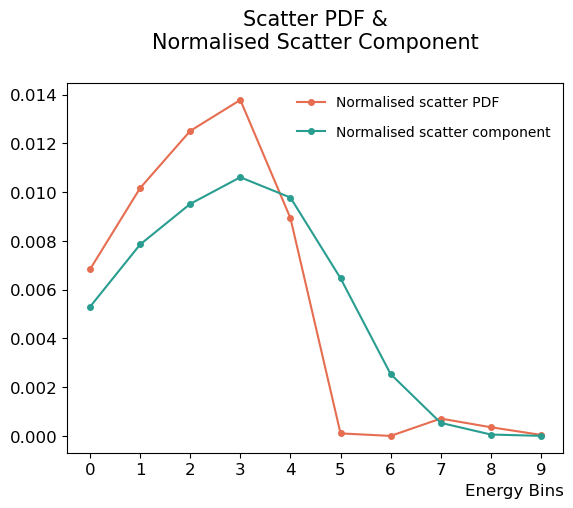

In [245]:
# Visualise the normalised scatter PDF and the normalised `blue1_pink0`
plt.plot(np.array(PDF_scatter), color = "#E66D50", label = "Normalised scatter PDF", marker = "o", ms = 4)
plt.plot(scatter, color = "#299D8F", label = "Normalised scatter component", marker = "o", ms = 4)
plt.xticks(np.arange(0, 10, 1), fontsize = 12)
plt.yticks(fontsize = 12)
plt.xlabel("Energy Bins", loc = "right", fontsize = 12)
plt.legend(loc = "upper right", frameon = False, fontsize = 10, labelspacing = 1.1)
plt.title("Scatter PDF &\nNormalised Scatter Component", pad=25, fontsize = 15)

In [246]:
# Method of moments
# Calculate the global a_1 and b_1
a_1 = 0
for i in range(10):
    a_1 += np.array(PDF_nonscatter)[i]*20*energies[i]
a_1

510.99312601940727

In [247]:
b_1 = 0
for i in range(10):
    b_1 += np.array(PDF_scatter)[i]*20*energies[i]
b_1

486.5915991154671

In [248]:
# and construct a matrix with a_1 and b_1
M = np.array([
    [1,      1,       1,       1],
    [a_1,    b_1,     a_1,     b_1],
    [a_1,    a_1,     b_1,     b_1],
    [a_1**2, a_1*b_1, a_1*b_1, b_1**2]
], dtype=float)

# Find the inverse of matrix M
M_inv = np.linalg.inv(M)

In [166]:
# Define the sinograms of sample moments
sinogram = PET.AcquisitionData(f"8.10/scatter_param=3/blue0_en{5}_pink0_en{5}.hs").as_array()
q00 = np.zeros(sinogram.shape)
q01 = np.zeros(sinogram.shape)
q10 = np.zeros(sinogram.shape)
q11 = np.zeros(sinogram.shape)

# Read the data into sinograms
for i in range(10):
    for j in range(10):
        sinogram = PET.AcquisitionData(f"8.10/scatter_param=3/blue0_en{i}_pink0_en{j}.hs").as_array()
        sinogram += PET.AcquisitionData(f"8.10/scatter_param=3/blue0_en{i}_pink1_en{j}.hs").as_array()
        sinogram += PET.AcquisitionData(f"8.10/scatter_param=3/blue1_en{i}_pink0_en{j}.hs").as_array()
        sinogram += PET.AcquisitionData(f"8.10/scatter_param=3/blue1_en{i}_pink1_en{j}.hs").as_array()
# Calculate the moments        
        q00 += sinogram
        q01 += sinogram * energies[j]
        q10 += sinogram * energies[i]
        q11 += sinogram * energies[i] * energies[j]

# Create a 5D matrix that records the four moments
q = np.stack((q00, q01, q10, q11))
q.shape

 Interfile warning: I have used all explicit settings for the scanner
	from the Interfile header, and remaining fields set from the
	ECAT 962 model.



Value in header is 1.27273 while the default for the scanner is 0.225
Using value from header.








	from the Interfile header, and remaining fields set from the
	ECAT 962 model.



Value in header is 1.27273 while the default for the scanner is 0.225
Using value from header.








	from the Interfile header, and remaining fields set from the
	ECAT 962 model.



Value in header is 1.27273 while the default for the scanner is 0.225
Using value from header.








	from the Interfile header, and remaining fields set from the
	ECAT 962 model.



Value in header is 1.27273 while the default for the scanner is 0.225
Using value from header.








	from the Interfile header, and remaining fields set from the
	ECAT 962 model.



Value in header is 1.27273 while the default for the scanner is 0.225
Using value from header.








	from

(4, 1, 12, 32, 55)

In [167]:
# Solve the matrix equation
sigma = np.tensordot(M_inv, q, axes=1)

In [168]:
# Organise sigma values
sigma0 = sigma[0,:,:,:,:]
sigma1 = sigma[1,:,:,:,:]
sigma2 = sigma[2,:,:,:,:]
sigma3 = sigma[3,:,:,:,:]

sigma_scatter = sigma1+sigma2+sigma3

You may need to close Figure 1 window to continue...


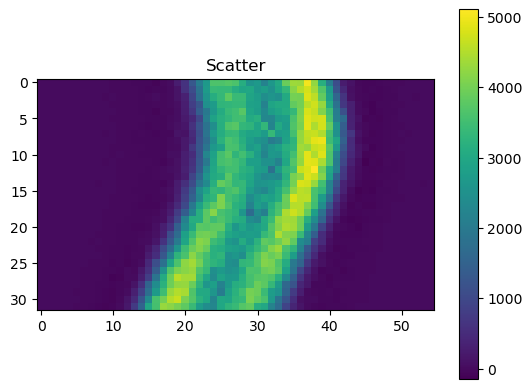

In [141]:
show_2D_array("Scatter", np.mean(sigma_scatter[0,:,:,:], axis = 0))

You may need to close Figure 1 window to continue...


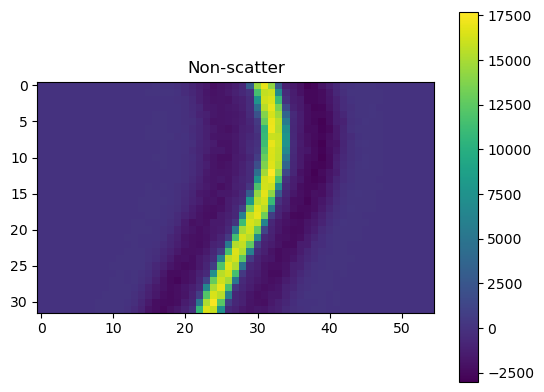

In [142]:
show_2D_array("Non-scatter", np.mean(sigma0[0,:,:,:], axis = 0))

In [197]:
# The scatter and non-scatter components as sinograms
nonscatter = np.zeros(sinogram.shape)
scatter = np.zeros(sinogram.shape)
for i in range(10):
    for j in range(10):
        nonscatter += PET.AcquisitionData(f"8.10/scatter_param=3/blue0_en{i}_pink0_en{j}.hs").as_array()
        scatter += PET.AcquisitionData(f"8.10/scatter_param=3/blue0_en{i}_pink1_en{j}.hs").as_array()
        scatter += PET.AcquisitionData(f"8.10/scatter_param=3/blue1_en{i}_pink0_en{j}.hs").as_array()
        scatter += PET.AcquisitionData(f"8.10/scatter_param=3/blue1_en{i}_pink1_en{j}.hs").as_array()

t for the scanner is 0.225
Using value from header.








	from the Interfile header, and remaining fields set from the
	ECAT 962 model.



Value in header is 1.27273 while the default for the scanner is 0.225
Using value from header.








	from the Interfile header, and remaining fields set from the
	ECAT 962 model.



Value in header is 1.27273 while the default for the scanner is 0.225
Using value from header.








	from the Interfile header, and remaining fields set from the
	ECAT 962 model.



Value in header is 1.27273 while the default for the scanner is 0.225
Using value from header.








	from the Interfile header, and remaining fields set from the
	ECAT 962 model.



Value in header is 1.27273 while the default for the scanner is 0.225
Using value from header.








	from the Interfile header, and remaining fields set from the
	ECAT 962 model.



Value in header is 1.27273 while the default for the scanner is 0.225
Using value from header.








	from the Inter

You may need to close Figure 1 window to continue...


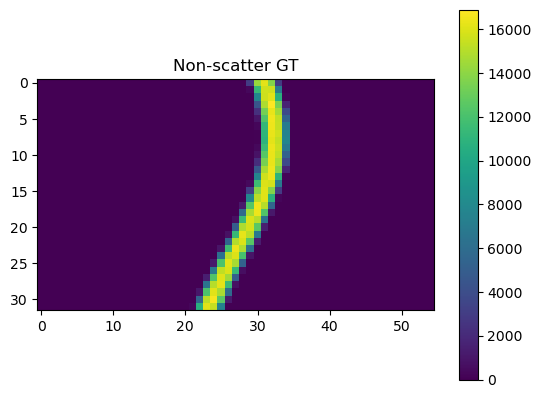

In [171]:
show_2D_array("Non-scatter GT", np.mean(nonscatter[0,:,:,:], axis = 0))

You may need to close Figure 1 window to continue...


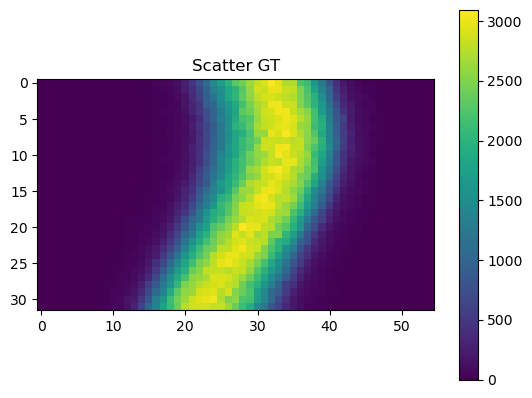

In [181]:
show_2D_array("Scatter GT", np.mean(scatter[0,:,:,:], axis = 0))

In [ ]:
plt.plot(np.mean(sigma_scatter[0,:,16,:], axis = 0), color = "#E66D50", label = "MoM scatter", marker = "o", ms = 4)
plt.plot(np.mean(scatter[0,:,16,:], axis = 0), color = "#299D8F", label = "Scatter component", marker = "o", ms = 4)
plt.yticks(fontsize = 12)
plt.legend(loc = "upper left", frameon = False, fontsize = 10, labelspacing = 1.1)
plt.title("MoM estimation and the scatter component", pad=25, fontsize = 15)

In [202]:
np.mean(scatter[0,:,16,:], axis = 0)

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       2.36114224e-01, 0.00000000e+00, 9.27204750e-01, 1.99223035e+00,
       5.76701142e+00, 8.73651585e+00, 1.85341559e+01, 2.46073191e+01,
       3.29236859e+01, 5.62702820e+01, 7.24194376e+01, 1.71931402e+02,
       3.19445432e+02, 5.23266773e+02, 8.97218332e+02, 1.22854476e+03,
       1.46201914e+03, 1.93868714e+03, 2.07386133e+03, 2.44421278e+03,
       2.57359748e+03, 2.74506184e+03, 3.00942777e+03, 3.04947546e+03,
       2.89369962e+03, 2.74377417e+03, 2.78069046e+03, 2.64330433e+03,
       2.28056367e+03, 1.85582242e+03, 1.40058607e+03, 1.02370946e+03,
       6.59008640e+02, 3.01128211e+02, 1.44149086e+02, 7.41231999e+01,
       5.46303277e+01, 2.13100350e+01, 1.87299586e+01, 7.71842992e+00,
       2.82118519e+00, 1.25571469e+00, 3.70997469e-01, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

Text(0.5, 1.0, 'MoM estimation and the non-scatter component')

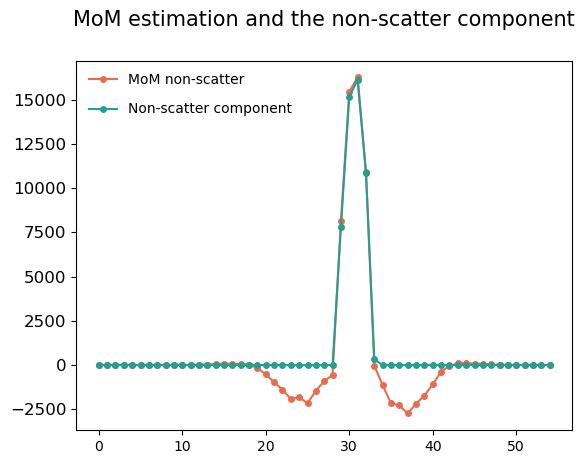

In [200]:
plt.plot(np.mean(sigma0[0,:,16,:], axis = 0), color = "#E66D50", label = "MoM non-scatter", marker = "o", ms = 4)
plt.plot(np.mean(nonscatter[0,:,16,:], axis = 0), color = "#299D8F", label = "Non-scatter component", marker = "o", ms = 4)
plt.yticks(fontsize = 12)
plt.legend(loc = "upper left", frameon = False, fontsize = 10, labelspacing = 1.1)
plt.title("MoM estimation and the non-scatter component", pad=25, fontsize = 15)